<a href="https://colab.research.google.com/github/pavanKarthik2006/Biocomputing/blob/main/Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('/content/DataPreprocessingGraded_dataset.csv')

In [3]:
df.shape

(748, 6)

In [4]:
df['Target']

,Target
0,YES
1,YES
2,YES
3,YES
4,NO
...,...
743,NO
744,NO
745,NO
746,NO


In [6]:
df.describe()

,V3,V4
count,748.000000,748.000000
mean,1378.676471,34.282086
std,1459.826781,24.376714
min,250.000000,2.000000
25%,500.000000,16.000000
50%,1000.000000,28.000000
75%,1750.000000,50.000000
max,12500.000000,98.000000


In [7]:
df_clean=df.dropna()

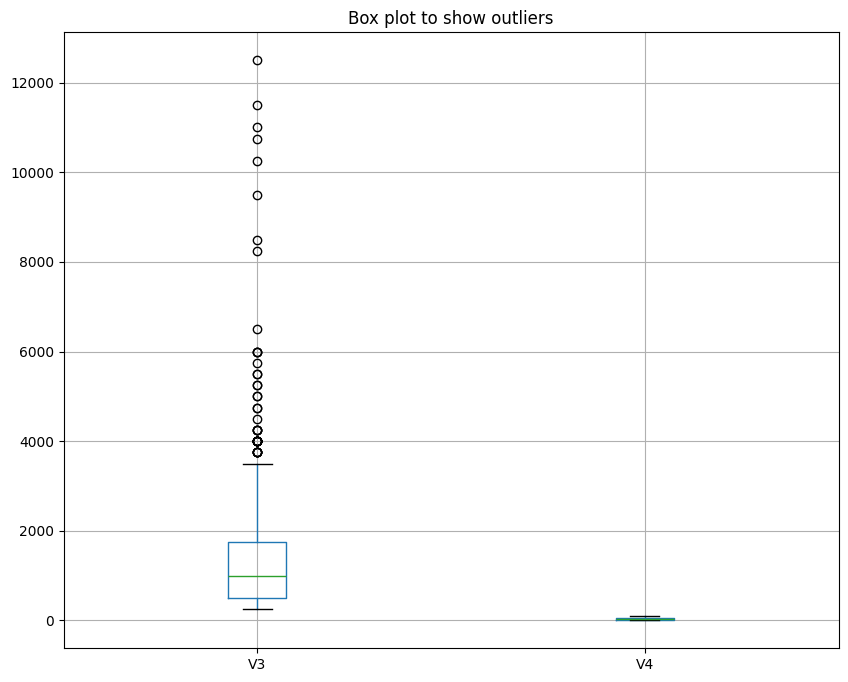

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols=df_clean.select_dtypes(include='number').columns
plt.figure(figsize=(10,8))
df_clean[num_cols].boxplot()
plt.title("Box plot to show outliers")
plt.show()

In [15]:
def count_outliers(series):
  q1=series.quantile(0.25)
  q3=series.quantile(0.75)
  iqr=q3-q1
  lower_bound=q1-1.5*iqr
  upper_bound=q3+1.5*iqr

  return((series<lower_bound)|(series>upper_bound)).sum()

outlier_count=df_clean[num_cols].apply(count_outliers).sort_values()
print(outlier_count)

V4     0
V3    45
dtype: int64


In [16]:
value=df['Target'].value_counts()
print(value)

Target
NO     570
YES    178
Name: count, dtype: int64


In [20]:
df.replace('?',np.nan,inplace=True)
ans=df.isnull().sum()
num_features_missing_Columns=(ans>0).sum()
print(num_features_missing_Columns)

2


In [23]:
from sklearn.impute import SimpleImputer

df['V1']=df['V1'].replace('?',np.nan)

df['V1']=pd.to_numeric(df['V1'])

imputer=SimpleImputer(strategy='median')
df['V1']=imputer.fit_transform(df[['V1']])

average_v1=df['V1'].mean()
print(average_v1)

9.552139037433156


In [28]:
from sklearn.impute import KNNImputer

df.replace('?',np.nan)

df=df.apply(pd.to_numeric,errors='coerce')

imputer=KNNImputer(n_neighbors=3)

df_new=imputer.fit_transform(df)

average=df_new[:,0].mean()
print(average)

9.552139037433156


In [32]:
from sklearn.impute import SimpleImputer

df['V2'].replace('?',np.nan)

df['V2']=pd.to_numeric(df['V2'])

imputer=SimpleImputer(strategy='mean')

df['V2']=imputer.fit_transform(df[['V2']])

average_v2=df['V2'].mean()
print(average_v2)

5.464333781965007
